# One-Day Hackathon Demo: Agentic Data Selection for Scientific Discovery

**Demo question:** Can a small research agent identify uncertain participant data and prevent a spurious scientific conclusion?

This notebook uses the public [SCI OPS dataset](https://github.com/nivlab/sciops) from Zorowitz et al. The associated study showed that careless or inattentive responses can create misleading associations between psychiatric symptom scores and cognitive task behavior.

The demo implements a compact agent loop:

1. **Inspect** participant-level quality and task metrics.
2. **Train** a calibrated classifier that predicts attention-check failure.
3. **Select** reliable data using hard and probabilistic policies.
4. **Audit** whether a symptom-to-behavior finding survives data selection.
5. **Query** the most uncertain participants for additional quality labels.

The required source CSV files are loaded directly from the workspace data folder, so the notebook works with the local SCI OPS dataset without needing an LLM API key. The planner is deterministic for reliability during a hackathon, while every analysis action is exposed as a tool that can later be selected by an LLM.

## Expected live demo

The unfiltered sample should suggest a statistically detectable negative relationship between anxiety symptoms and task accuracy. After excluding participants who fail infrequency checks, the relationship should largely disappear. The learned selector should move the result toward the quality-controlled estimate without directly using anxiety scores as features.

This is the key scientific discovery lesson: a predictive pattern is not automatically a robust scientific finding.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

from sklearn.calibration import CalibrationDisplay
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    RocCurveDisplay,
    average_precision_score,
    brier_score_loss,
    classification_report,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.style.use("seaborn-v0_8-whitegrid")

## 1. Load the public data

In [2]:
from pathlib import Path

DATA_DIR = Path.cwd() / "01_Original" / "data"

# Load the local SCI OPS CSVs instead of the embedded gzip payloads.
metrics = pd.read_csv(DATA_DIR / "metrics.csv")
scores = pd.read_csv(DATA_DIR / "scores.csv")
data = metrics.merge(scores, on=["platform", "subject"], how="inner")

# Proxy target supplied by the study: at least one failed infrequency item.
data["careless"] = (data["infreq"] > 0).astype(int)

print("Loaded local SCI OPS data from 01_Original/data.")
print(f"Participants: {len(data):,}")
print(f"Attention-check failure rate: {data['careless'].mean():.1%}")
data.head(3)


Loaded local SCI OPS data from 01_Original/data.
Participants: 386
Attention-check failure rate: 22.0%


,platform,subject,infreq_gad7,infreq_7u7d,infreq_bisbas,infreq_shaps,infreq,isd,reliability,mahalanobis,...,wsls,task_rt,7u,7d,gad7,pswq,bis,bas,shaps,careless
0,mturk,02rwq76tp9lcye8vrl41llnh,1,1,0,1,3,5.518530,0.212373,9.826776,...,0.537422,0.088889,12,11,15,6,7,17,13,1
1,mturk,0a8zkiu9rpf0mxo0h9ecdyzh,0,0,0,0,0,4.296821,0.824700,8.121987,...,0.909769,0.033333,1,5,11,7,5,17,10,0
2,mturk,0g4fx9g2wryeio74yzgqwpq8,0,0,0,0,0,1.903397,0.939701,4.435628,...,0.625000,0.433333,0,0,0,1,9,14,12,0


## 2. Define a leakage-safe selector

The selector predicts attention-check failure using task behavior, timing, response consistency, and multivariate quality metrics. It does **not** use:

1. The infrequency items that define the target.
2. Anxiety or other symptom scores used in the downstream scientific claim.

Out-of-fold probabilities are used so every participant is scored by a model that was not trained on that participant.

In [3]:
FEATURES = [
    "isd",
    "reliability",
    "mahalanobis",
    "survey_rt",
    "variability",
    "accuracy",
    "wsls",
    "task_rt",
]
TARGET = "careless"

selector = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("model", LogisticRegression(max_iter=2_000, class_weight="balanced")),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
data["p_careless"] = cross_val_predict(
    selector,
    data[FEATURES],
    data[TARGET],
    cv=cv,
    method="predict_proba",
)[:, 1]

selector_metrics = {
    "AUROC": roc_auc_score(data[TARGET], data["p_careless"]),
    "Average precision": average_precision_score(data[TARGET], data["p_careless"]),
    "Brier score": brier_score_loss(data[TARGET], data["p_careless"]),
}
pd.Series(selector_metrics).round(3).to_frame("score")

,score
AUROC,0.755
Average precision,0.524
Brier score,0.191


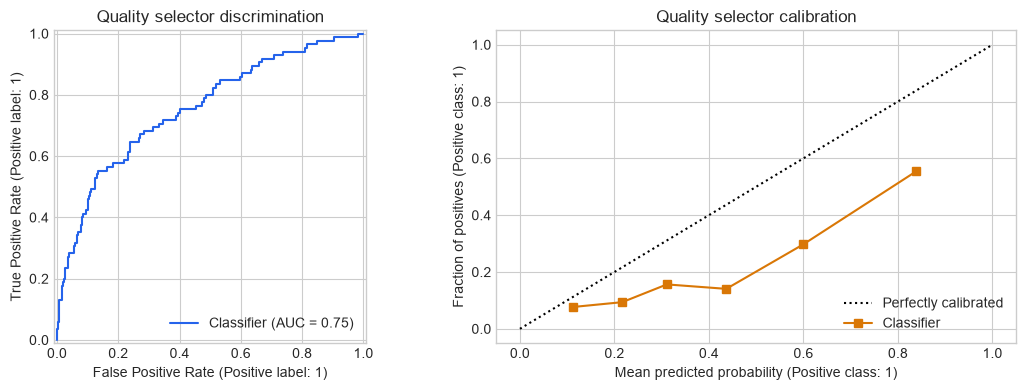

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
# sklearn >=1.9: line styling goes through curve_kwargs, not **kwargs
RocCurveDisplay.from_predictions(
    data[TARGET], data["p_careless"], ax=axes[0],
    curve_kwargs={"color": "#2563eb"},
)
axes[0].set_title("Quality selector discrimination")

CalibrationDisplay.from_predictions(
    data[TARGET], data["p_careless"], n_bins=6, strategy="quantile",
    ax=axes[1], color="#d97706"
)
axes[1].set_title("Quality selector calibration")
plt.tight_layout()
plt.show()

## 3. Treat data inclusion as uncertain

We compare four policies:

| Policy | Meaning |
| --- | --- |
| All data | Standard analysis with no quality control |
| Oracle clean | Exclude participants who failed an infrequency item |
| Agent hard | Include participants when predicted failure probability is below 0.5 |
| Agent weighted | Keep everyone but weight them by predicted attentiveness, $1-p_{careless}$ |

`Oracle clean` is an evaluation reference, not information available to the selector at inference time.

In [5]:
def weighted_corr(x, y, w):
    x, y, w = map(np.asarray, (x, y, w))
    w = w / w.sum()
    mx, my = np.sum(w * x), np.sum(w * y)
    cov = np.sum(w * (x - mx) * (y - my))
    vx = np.sum(w * (x - mx) ** 2)
    vy = np.sum(w * (y - my) ** 2)
    return cov / np.sqrt(vx * vy)


def correlation_row(name, frame, weights=None):
    if weights is None:
        r, p = pearsonr(frame["gad7"], frame["accuracy"])
    else:
        r = weighted_corr(frame["gad7"], frame["accuracy"], weights)
        p = np.nan
    return {"policy": name, "n": len(frame), "correlation": r, "p_value": p}


agent_mask = data["p_careless"] < 0.50
results = pd.DataFrame([
    correlation_row("All data", data),
    correlation_row("Oracle clean", data.loc[data[TARGET] == 0]),
    correlation_row("Agent hard", data.loc[agent_mask]),
    correlation_row("Agent weighted", data, 1 - data["p_careless"]),
])
results.round(4)

,policy,n,correlation,p_value
0,All data,386,-0.1217,0.0168
1,Oracle clean,301,0.0062,0.9141
2,Agent hard,258,0.0280,0.6542
3,Agent weighted,386,-0.0692,NaN


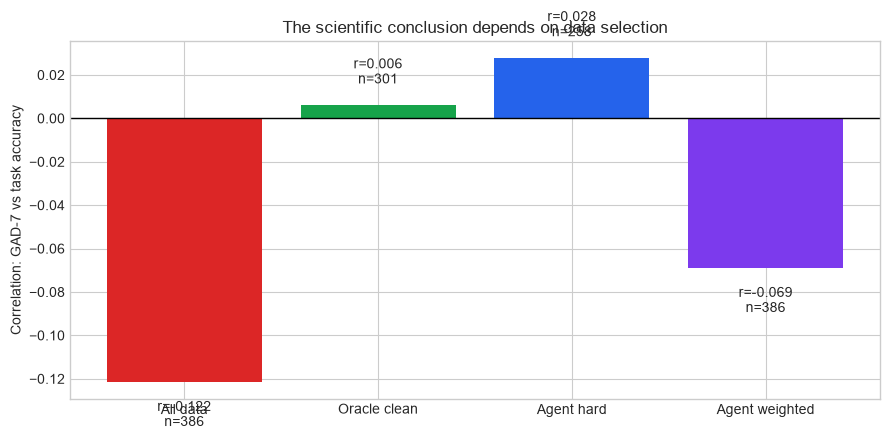

In [6]:
colors = ["#dc2626", "#16a34a", "#2563eb", "#7c3aed"]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(results["policy"], results["correlation"], color=colors)
ax.axhline(0, color="black", linewidth=1)
ax.set_ylabel("Correlation: GAD-7 vs task accuracy")
ax.set_title("The scientific conclusion depends on data selection")
for i, row in results.iterrows():
    ax.text(i, row["correlation"] - 0.008 if row["correlation"] < 0 else row["correlation"] + 0.008,
            f"r={row['correlation']:.3f}\nn={int(row['n'])}",
            ha="center", va="top" if row["correlation"] < 0 else "bottom")
plt.tight_layout()
plt.show()

## 4. Ask for the most useful additional labels

The agent should not pretend that a probability near 0.5 is a confident inclusion decision. The next action is to request an additional quality check for the participants closest to the decision boundary.

In [7]:
query_queue = (
    data.assign(uncertainty=1 - 2 * np.abs(data["p_careless"] - 0.5))
        .sort_values("uncertainty", ascending=False)
        .loc[:, ["subject", "p_careless", "uncertainty", "accuracy", "task_rt", "survey_rt"]]
        .head(10)
)
query_queue.round(3)

,subject,p_careless,uncertainty,accuracy,task_rt,survey_rt
202,3qz20dlryiffihwsltdnk6cn,0.501,0.998,0.322,0.567,25.861
112,l768h0oa3rsy0s30wy81gx7w,0.502,0.995,0.589,0.067,10.983
193,1i545xikf02ck7ekr6psckaq,0.497,0.993,0.522,0.622,10.719
89,h1pemdlnh3c9vhbgryg1ixhn,0.496,0.992,0.544,0.756,18.268
131,pbe1z8nw3u49kut6yzpm5d8d,0.496,0.991,0.600,0.322,20.368
226,9kzs2lfi4bmyk5xz03ck58ne,0.495,0.991,0.622,0.711,22.310
252,dfr3ft3vadd2ecq1pqhkiiid,0.495,0.990,0.578,0.111,30.954
200,2sdnu1yjjuxyew3zpe8nwlhb,0.493,0.986,0.589,0.667,27.397
95,hjga6ro8xdcijnzxcabiekgh,0.507,0.985,0.678,0.022,9.949
65,deuoj5f7ihyov9fdc56skfam,0.508,0.983,0.589,0.156,9.479


## 5. A minimal tool-using research agent

In [8]:
def train_selector_tool():
    return {
        "action": "train_selector",
        "result": selector_metrics,
        "interpretation": "The classifier contains useful but imperfect quality information.",
    }


def audit_claim_tool():
    all_r = results.loc[results.policy == "All data", "correlation"].iloc[0]
    clean_r = results.loc[results.policy == "Oracle clean", "correlation"].iloc[0]
    changed = np.sign(all_r) != np.sign(clean_r) or abs(all_r - clean_r) > 0.08
    return {
        "action": "audit_scientific_claim",
        "result": {"all_data_r": all_r, "quality_controlled_r": clean_r},
        "interpretation": "The claim is selection-sensitive." if changed else "The claim is stable.",
    }


def select_queries_tool(budget=10):
    return {
        "action": "request_quality_labels",
        "result": query_queue.head(budget)["subject"].tolist(),
        "interpretation": f"Query {budget} ambiguous participants before making a final claim.",
    }


TOOLS = {
    "train_selector": train_selector_tool,
    "audit_claim": audit_claim_tool,
    "select_queries": select_queries_tool,
}


def run_research_agent(plan=("train_selector", "audit_claim", "select_queries")):
    trace = []
    for tool_name in plan:
        trace.append(TOOLS[tool_name]())
    return trace


agent_trace = run_research_agent()
pd.DataFrame(agent_trace)[["action", "interpretation"]]

,action,interpretation
0,train_selector,The classifier contains useful but imperfect q...
1,audit_scientific_claim,The claim is selection-sensitive.
2,request_quality_labels,Query 10 ambiguous participants before making ...


## 6. Reactive agent loop with process traces

Section 5's agent runs a **fixed plan** — `train -> audit -> query`, every time. Nothing it observes
can change what it does next, so it cannot do the thing the proposal asks for: notice the evidence is
ambiguous and go get more of it.

This section replaces it with a genuinely reactive loop, and records **what the agent did**, not just
what it concluded.

### Why trace the process

Scoring only the final answer cannot tell systematic reasoning apart from a lucky guess. Two runs here
can both conclude *"gad7 is selection-sensitive"* while one compared four policies and bought extra
attention checks and the other guessed. The claim cannot distinguish them. The trace can — and it is
also what makes the analysis auditable, which is the whole point of the project.

Each step records nine fields:

`step_id, timestamp, phase, thought, action{type,tool,input,output}, observation,
error{occurred,type,message}, revision_trigger, confidence`

plus a trajectory-level `outcome` and `metadata`. Errors are classified as **code_error**,
**reasoning_error**, or **hallucination** — "called the tool wrong" and "reasoned wrong" are different
problems needing different fixes, and a single error count hides that.

Two fields are specific to this project:

| field | why |
| --- | --- |
| `phase` → `inspect, quality_model, policy_comparison, budget_request, replication, revision, conclusion` | a data-selection vocabulary rather than a generic discovery one; `PHASE_MAP` translates to generic names if traces need comparing elsewhere |
| `outcome.selection_sensitivity` | whether a claim survives alternative defensible selections — this project's entire question |

Ratings come from **you**, below.

In [9]:
import importlib
import sciops_agent as agent, trace_ui as ui, trace_schema, llm_backends
for m in (trace_schema, llm_backends, agent, ui):
    importlib.reload(m)          # re-run after editing any of these files

print("mode  : generated-code ReAct (no model-facing tools)")
print("phases:", ", ".join(trace_schema.PHASE_MAP))
print(f"\nbackend (auto) -> {llm_backends.resolve()}")
print(f"  aitta model     : {llm_backends.AITTA_MODEL}")
print(f"  aitta base_url  : {llm_backends.AITTA_BASE_URL}")
print("\nEvery step records phase / rationale / confidence / generated code / observation.")
print("Generated Python runs in a restricted local executor and is retained in the JSON trace.")

mode  : generated-code ReAct (no model-facing tools)
phases: inspect, quality_model, policy_comparison, budget_request, replication, revision, conclusion

backend (auto) -> scripted
  aitta model     : openai/gpt-oss-120b
  aitta base_url  : https://aitta-api.csc.fi/openai/v1

Every step records phase / rationale / confidence / generated code / observation.
Generated Python runs in a restricted local executor and is retained in the JSON trace.


### 6.1 Ask a question

Type a research question, pick a backend, run.

| backend | what it is | needs |
| --- | --- | --- |
| **`aitta`** | CSC-hosted JSON/code generation | `AITTA_API_KEY` |
| `openai` | OpenAI JSON/code generation | `OPENAI_API_KEY` or `config.py` |
| `anthropic` | Claude JSON/code generation | `ANTHROPIC_API_KEY` |
| `scripted` | executes a deterministic generated-code trajectory | nothing |

`auto` picks the first one whose key is set.

```bash
# token from https://aitta-auth.csc.fi/myToken
export AITTA_API_KEY="..."
```

The model receives no function schemas. It returns JSON-wrapped Python, the restricted executor
runs it against local DataFrames, and the observation is fed into the next ReAct turn.

Check what Aitta is actually serving with `llm_backends.list_aitta_models()`.

In [10]:
ui.ask()

### 6.2 Rate what it did

Read the trace and score it. Your rating and critique are written to `traces/` and injected into the
next run's system prompt — ratings ≥4 as exemplars, ≤2 as anti-patterns. **The critique text is shown
to the agent verbatim**, so write it for that audience.

This is the human-in-the-loop input. There is no JSON to edit.

In [11]:
ui.rate()          # rates the run from 6.1

No trajectory yet — run ui.ask() first.


In [12]:
ui.browse()        # everything rated so far

No rated trajectories yet. Run ui.ask() then ui.rate().


### 6.3 The loop is closed

Confirm your rating reached the prompt.

In [13]:
seed_only = agent.build_system_prompt(include_rated=False)
with_yours = agent.build_system_prompt()

print(f"seed exemplars only : {len(seed_only):,} chars")
print(f"+ your rated runs   : {len(with_yours):,} chars")
for t in agent._rated_from_disk():
    print(f"   [{t['rating']}/5] {t['label']}")

traj = ui.last()
if traj is not None:
    print(f"\nlast run: {traj.summary()}")
    if traj.outcome:
        print(f"verdict : {traj.outcome.selection_sensitivity.verdict}")
        for lim in traj.outcome.limitations:
            print(f"  could not determine: {lim}")

seed exemplars only : 6,534 chars
+ your rated runs   : 6,534 chars


### 6.4 Process metrics the final answer cannot show

Two runs that reach the same conclusion can differ completely here — that difference is the result.

In [14]:
import pandas as pd

rated = ui.load_rated()
runs = [t for t in [ui.last()] if t is not None] or rated
if runs:
    rows = [{
        "trajectory": t.trajectory_id[-8:],
        "steps": t.metadata.total_steps,
        "code_executions": t.metadata.total_code_executions,
        "errors": t.metadata.total_failures,
        "revisions": t.metadata.total_revisions,
        "mean_confidence": round(
            sum(s.confidence for s in t.trace if s.confidence is not None)
            / max(1, sum(1 for s in t.trace if s.confidence is not None)), 2),
        "phases_visited": len({s.phase for s in t.trace}),
        "verdict": t.outcome.selection_sensitivity.verdict if t.outcome else "—",
        "human": t.human_rating.rating if t.human_rating else None,
    } for t in runs]
    display(pd.DataFrame(rows))
else:
    print("Run 6.1 first.")

Run 6.1 first.


### 6.5 Extending this

- **Extend the code environment** by adding an explicitly permitted object to `code_runner.py`.
  The model still receives no callable tool schema; every action remains generated Python.
- **Rate several runs of the same question** and watch the *trajectory* vary even when the answer
  does not. Trajectory variance under a fixed question is itself a result.
- **The samples are less comparable than they look.** Original measures `accuracy`/`variability`;
  the replication measures `choice_var`/`side_var`. Only `wsls` is common, so a selector on the full
  8-feature list **cannot be applied to the replication sample at all**. `transfer_selector` uses the
  6 shared features — AUROC 0.728 vs 0.755 in-sample, across two different cognitive tasks.

## 7. Demo conclusion

The notebook demonstrates three behaviors expected from an agent for scientific discovery:

1. It trains a real classifier and reports discrimination plus calibration.
2. It represents participant inclusion as a probability rather than an unquestioned preprocessing choice.
3. It tests whether a scientific conclusion survives alternative data selection policies.

The expected result is that the apparent relationship between GAD-7 anxiety scores and task accuracy is visible in the full sample but becomes much smaller after quality control. The correct agent response is therefore not “anxiety predicts poor task performance.” It is “the apparent association is sensitive to participant quality and should not be treated as robust without additional evidence.”

### If there is extra hackathon time

1. Replace the deterministic plan with an LLM that selects from the three registered tools.
2. Add bootstrap intervals to the policy comparison.
3. Validate the selector on the repository's replication sample.
4. Add diversity-aware active querying instead of uncertainty alone.

### Sources

1. [Zorowitz et al. paper](https://pmc.ncbi.nlm.nih.gov/articles/PMC11170515/)
2. [SCI OPS data and code](https://github.com/nivlab/sciops)
3. [OpenCogData catalogue](https://nimh-dsst.github.io/OpenCogData/)